In [1]:
import earthaccess,csv
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
from scipy.ndimage import median_filter
from scipy.interpolate import LinearNDInterpolator
from scipy.ndimage import generic_filter

In [2]:
%pip install jaxparrow
from jaxparrow import cyclogeostrophy
from jaxparrow import geostrophy
import jax.numpy as jnp
import jaxparrow as jxr

  Using cached jaxparrow-0.2.3-py3-none-any.whl.metadata (6.1 kB)
  Using cached jax-0.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.7.1-cp311-cp311-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
  Using cached jaxtyping-0.3.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached optax-0.2.5-py3-none-any.whl.metadata (7.5 kB)
  Using cached ml_dtypes-0.5.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.9 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached wadler_lindig-0.1.7-py3-none-any.whl.metadata (17 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached chex-0.1.91-py3-none-any.whl.metadata (18 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached jaxparrow-0.2.3-py3-none-any.whl (25 kB)
Using cached jax-0.7.1-py3-none-any.whl (2.8 MB)
Using cached jaxlib-0.7.1-cp311-cp311-manylinux_2_27_x86_64.whl (81.1 MB)
Using cached jaxtyping-0.3.2-py3-none-any

In [113]:
# conda install conda-forge::pyinterp

In [3]:
# conda install pyinterp

Channels:
 - conda-forge
Platform: linux-64
Solving environment: | 
Note: you may need to restart the kernel to use updated packages.


In [112]:
# %pip install widetrax

In [110]:
# import widetrax
# from widetrax import Spectra as sp
# from widetrax import DataPreprocessing as dp
# from widetrax import Grads as gr

In [18]:
%%bash
python --version

Python 3.11.11


In [9]:
date_requested = '20240508'
pacedate="2024-05-08"

In [10]:
aviso_ds = xr.open_dataset('data/eddy_trajectories/Edward_Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20240723.nc')

In [11]:
dates = [i for i in aviso_ds.time.values] # these are sorted already
print(min(dates))
print(max(dates)) # still existed at the end of the dataset
tminny=str(min(dates))
tminny=tminny[0:10]
tmaxxy=str(max(dates))
tmaxxy=tmaxxy[0:10]
tmin,tmax = tminny,tmaxxy
center_lats = [i for i in aviso_ds.latitude.values]
center_lons = [i for i in aviso_ds.longitude.values]
print(len(center_lats))
print(min(center_lats))
print(max(center_lats))
print(min(center_lons)-360)
print(max(center_lons)-360)
#Define box based on eddy
latmin,latmax = min(center_lats)-2,max(center_lats)+2
lonmin,lonmax = min(center_lons)-360-2,max(center_lons)-360+2

2023-12-14T00:00:00.000000000
2024-07-23T00:00:00.000000000
223
35.502697
36.847385
-71.77410888671875
-67.88714599609375


In [12]:
auth = earthaccess.login(persist=True)

In [13]:
def get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax):
    """
    Searches for SWOT data within the bounding box and time. Note that this doesn't work for unsmoothed data. 
    
    latmin,latmax: latitude bounds, degrees N (south is negative); floats
    lonmin, lonmax: longitude bounds, degrees E (west is negative); floats
    tmin,tmax: temporal bounds; strings of form 'yyyy-mm-dd'
    """
    bbox = (lonmin, latmin, lonmax, latmax) # lonW, latS, lonE, latN
    results = earthaccess.search_data(
        short_name="SWOT_L2_LR_SSH_EXPERT_2.0",
        bounding_box=bbox,
        temporal=(tmin,tmax))
    
    print("Number of swaths: " + str(len(results))) # not daily files, so will likely be more than # of days
    paths = earthaccess.open(results) # is there a way to choose a subset of variables here?

    return paths

In [14]:
eddy_paths = get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax)

Number of swaths: 242


QUEUEING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/242 [00:00<?, ?it/s]

In [15]:
ind = 0 
for i in eddy_paths:
    today = str(i).split('-')[-1].split('_')[-4][0:8]
    if date_requested == today:
        print(ind)
        sel=ind
    ind += 1

166
167


In [16]:
ds1 = xr.open_dataset(eddy_paths[sel])
ds2 = xr.open_dataset(eddy_paths[sel-1])

In [17]:
def crop_dataset_by_lat_lon(ds,latmin,latmax,lonmin,lonmax):
    mask = (ds.latitude >= latmin) & (ds.latitude <= latmax) & (ds.longitude >= lonmin+360) & (ds.longitude <= lonmax+360)
    ds_masked = ds.where(mask, drop=True)
    return ds_masked

In [18]:
ds1_masked = crop_dataset_by_lat_lon(ds1,latmin,latmax,lonmin,lonmax)
ds2_masked = crop_dataset_by_lat_lon(ds2,latmin,latmax,lonmin,lonmax)

In [19]:
ds=ds1_masked
ssh=ds.ssha_karin_2+ds.height_cor_xover
lats=ds.latitude
lons=ds.longitude
ds=ds.assign(ssha=ssh)

In [20]:
ds2=ds2_masked
ssh2=ds2.ssha_karin_2+ds.height_cor_xover
lats2=ds2.latitude
lons2=ds2.longitude
ds2=ds2.assign(ssha=ssh2)

In [121]:
ug, vg, j, j1, j12, j3 = geostrophy(jnp.array(ssh),jnp.array(lats),jnp.array(lons))
ug2, vg2, j, j1, j12, j3 = geostrophy(jnp.array(ssh2),jnp.array(lats2),jnp.array(lons2)) #they inversed this!

In [122]:
u_cyclo_2d, v_cyclo_2d, j, j1, j12, j3 =cyclogeostrophy(jnp.array(ssh),jnp.array(lats),jnp.array(lons))
u_cyclo_2d_2, v_cyclo_2d_2, j, j1, j12, j3 =cyclogeostrophy(jnp.array(ssh2),jnp.array(lats2),jnp.array(lons2))

In [96]:
#Following function written with assistance of AI
def remove_swath_edges(data_array, edge_pixels):
    """
    Simple approach: remove edge pixels from all continuous non-NaN segments
    """
    result = jnp.array(data_array)
    n_rows, n_cols = data_array.shape
    
    for i in range(n_rows):
        # Convert to numpy for gap detection
        row_data = np.array(data_array[i, :])
        valid_mask = ~np.isnan(row_data)
        
        # Find where valid data starts and ends
        if np.any(valid_mask):
            # Find all valid segments
            diff = np.diff(valid_mask.astype(int))
            segment_starts = np.where(diff == 1)[0] + 1
            segment_ends = np.where(diff == -1)[0] + 1
            
            # Handle edge cases
            if valid_mask[0]:
                segment_starts = np.insert(segment_starts, 0, 0)
            if valid_mask[-1]:
                segment_ends = np.append(segment_ends, n_cols)
            
            # Remove edges from each segment
            for start, end in zip(segment_starts, segment_ends):
                if (end - start) > 2 * edge_pixels:
                    # Remove left edge
                    result = result.at[i, start:start + edge_pixels].set(jnp.nan)
                    # Remove right edge
                    result = result.at[i, end - edge_pixels:end].set(jnp.nan)
    
    return result

In [40]:
# Remove edge of swath due to edge effects in vg and v_cyclo. Please note that this function was written with the assistance of AI
def remove_swath_edges(data_array, edge_pixels):
    """
    Remove edge pixels from SWOT swath - optimized version
    """
    # Directly set edge pixels to NaN without creating a separate mask
    result = data_array.at[:, :edge_pixels].set(jnp.nan)
    result = data_array.at[:, -edge_pixels:].set(jnp.nan)
    return result

In [61]:
np.shape(ug)

(318, 69)

In [57]:
ds.num_pixels

<xarray.DataArray 'num_pixels' (num_pixels: 69)> Size: 552B
array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68])
Dimensions without coordinates: num_pixels

In [123]:
pixel_num=2 #This number will change per 
ug = remove_swath_edges(ug, edge_pixels=pixel_num)
ug2 = remove_swath_edges(ug2,edge_pixels=pixel_num)
vg = remove_swath_edges(vg,edge_pixels=pixel_num)
vg2 = remove_swath_edges(vg2,edge_pixels=pixel_num)

In [124]:
pixel_num=2 #This number will change per 
ucyclo = remove_swath_edges(u_cyclo_2d, edge_pixels=pixel_num)
ucyclo2 = remove_swath_edges(u_cyclo_2d_2, edge_pixels=pixel_num)
vcyclo = remove_swath_edges(v_cyclo_2d, edge_pixels=pixel_num)
vcyclo2 = remove_swath_edges(v_cyclo_2d_2, edge_pixels=pixel_num)

In [125]:
#Clean up cyclogeostrophic velocities. Artifacts above 5 m/s (also, unrealistic?)
ucyclo=np.array(ucyclo)
ucyclo[np.abs(ucyclo) > 5] = np.nan

ucyclo2=np.array(ucyclo2)
ucyclo2[np.abs(ucyclo2) > 5] = np.nan

vcyclo=np.array(vcyclo)
vcyclo[np.abs(vcyclo) > 5] = np.nan

vcyclo2=np.array(vcyclo2)
vcyclo2[np.abs(vcyclo2) > 5] = np.nan

<Figure size 640x480 with 0 Axes>

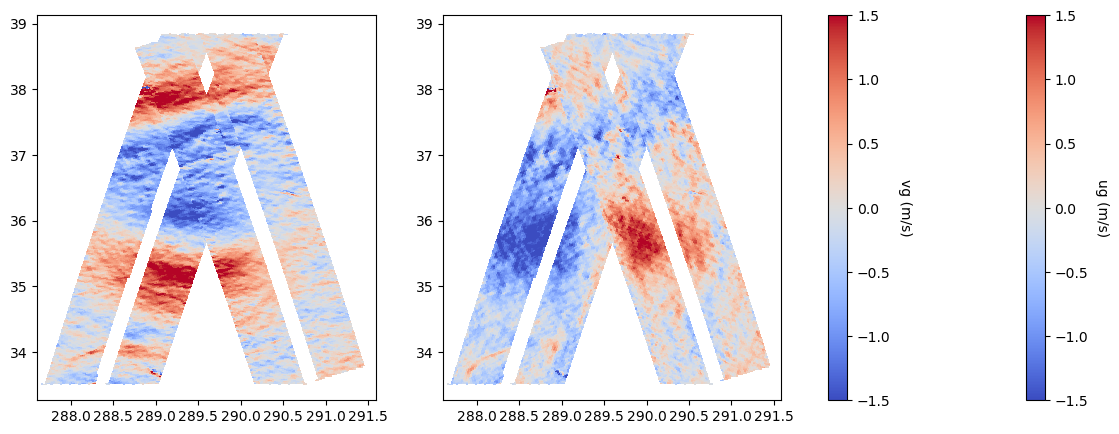

In [126]:
vel=1.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,ug,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,-ug2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('ug (m/s)', rotation=270, labelpad=15)

# plot = ax.pcolormesh(grid_x,grid_y,ug2,cmap='coolwarm',vmin=-1,vmax=1)
# ax.plot(contour_lons,contour_lats,zorder=100,c='k',linewidth=2)


plot = ax[1].pcolormesh(lons,lats,vg,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,-vg2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('vg (m/s)', rotation=270, labelpad=15)

<Figure size 640x480 with 0 Axes>

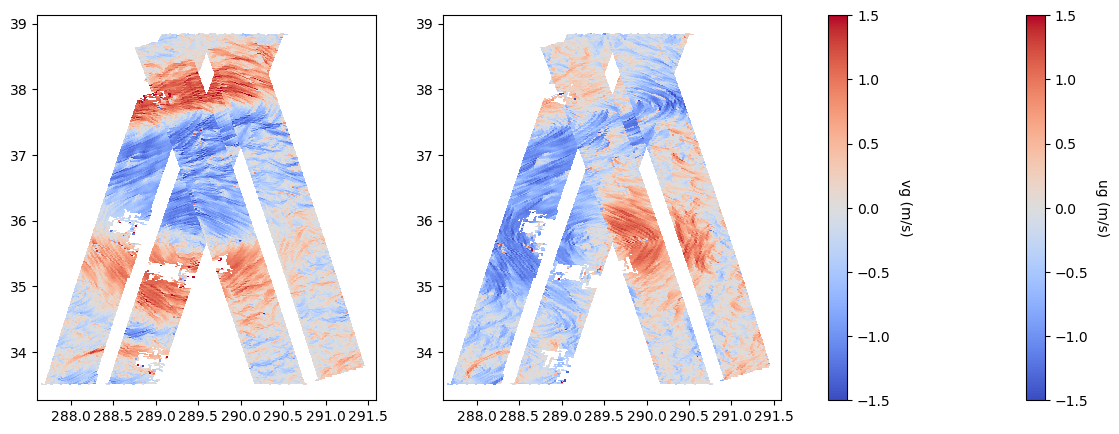

In [127]:
vel=1.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,ucyclo,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,-ucyclo2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('ug (m/s)', rotation=270, labelpad=15)

# plot = ax.pcolormesh(grid_x,grid_y,ug2,cmap='coolwarm',vmin=-1,vmax=1)
# ax.plot(contour_lons,contour_lats,zorder=100,c='k',linewidth=2)


plot = ax[1].pcolormesh(lons,lats,vcyclo,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,-vcyclo2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('vg (m/s)', rotation=270, labelpad=15)

In [186]:
# Compare geostrophic vorticity with vorticity calculated from cyclogeostrophic currents
def compute_normalized_vorticity_strain(data_array,u,v,wfl):

    lats = jnp.array(data_array.latitude.values)
    lons = jnp.array(data_array.longitude.values)

    dx, dy = jxr.tools.geometry.compute_spatial_step(lats, lons)
    mask = np.zeros_like(u)

    #Smoothing code is under construction here... this snippet of smoothing code written with help of AI (as you can likely tell...)
    #I'm still trying to figure out why just simply running the generic filter on u and v is cutting the swath substantially, whereas this code retains swath width...
    #I'll come back to this, but it does work well for now.
    def direct_2d_swath_smoothing(u_geos_u, lat, lon, window_size=5, angle_tolerance=30):
        """
        Modified version of your original code for 2D smoothing
        """
        # Calculate track direction (same as original)
        dy = np.gradient(lat, axis=0)
        dx = np.gradient(lon, axis=0)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            track_angle = np.arctan2(dy, dx)
            track_angle = np.nan_to_num(track_angle, nan=0.0)
        
        # Use the same window size for both directions
        footprint = np.ones((window_size, window_size), dtype=bool)
        
        def simple_2d_filter(values):
            """Simplified 2D version of your original filter"""
            center_idx = len(values) // 2
            if np.isnan(values[center_idx]):
                return np.nan
            
            # Get center point's track angle
            center_angle = track_angle.flat[center_idx]
            
            # Calculate angular differences
            window_angles = track_angle.flat[:len(values)]
            angle_diffs = np.abs(window_angles - center_angle)
            angle_diffs = np.minimum(angle_diffs, 2*np.pi - angle_diffs)
            
            # Create mask for points along track
            along_track_mask = angle_diffs < np.radians(angle_tolerance)
            valid_mask = ~np.isnan(values)
            
            # Use ALL valid points along track (no distance weighting)
            final_mask = along_track_mask & valid_mask
            
            if np.any(final_mask):
                return np.mean(values[final_mask])  # Simple average
            else:
                return values[center_idx]
    
        smoothed = generic_filter(u_geos_u, simple_2d_filter, footprint=footprint, mode='nearest', cval=np.nan)
        # Apply the filter (this now does 2D smoothing following swath direction)
        return smoothed
   
    # u=generic_filter(u, np.mean, size=[wfl,wfl], mode='nearest')
    # v=generic_filter(v, np.mean, size=[wfl,wfl], mode='nearest')

    u=direct_2d_swath_smoothing(u, lats, lons, window_size=wfl)
    v=direct_2d_swath_smoothing(v, lats, lons, window_size=wfl)

    # Compute derivatives
    dv_dx = jxr.tools.operators.derivative(v, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    du_dy = jxr.tools.operators.derivative(u, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    du_dx = jxr.tools.operators.derivative(u, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    dv_dy = jxr.tools.operators.derivative(v, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    #Compute coriolis for normalization
    omega = 7.2921159e-05  # angular velocity of the Earth [rad/s]
    fc = 2*omega*np.sin(lats*np.pi/180.)
        
    # avoid zero near equator, bound fc by min val as 1.e-8
    f_coriolis = np.sign(fc)*np.maximum(np.abs(fc), 1.e-8)

    vorticity = dv_dx - du_dy / f_coriolis
    strain= np.sqrt((du_dx - dv_dy)**2 + (du_dy + dv_dx) ** 2)
    strain=strain/f_coriolis 

    return vorticity,strain

In [208]:
vort,strain=compute_normalized_vorticity_strain(ds,ug,vg,8)
vort2,strain2=compute_normalized_vorticity_strain(ds2,ug2,vg2,8) 

In [209]:
pixel_num=2 #This number will change per 
vort = remove_swath_edges(vort, edge_pixels=pixel_num)
vort2 = remove_swath_edges(vort2,edge_pixels=pixel_num)
strain = remove_swath_edges(strain,edge_pixels=pixel_num)
strain2 = remove_swath_edges(strain2,edge_pixels=pixel_num)

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

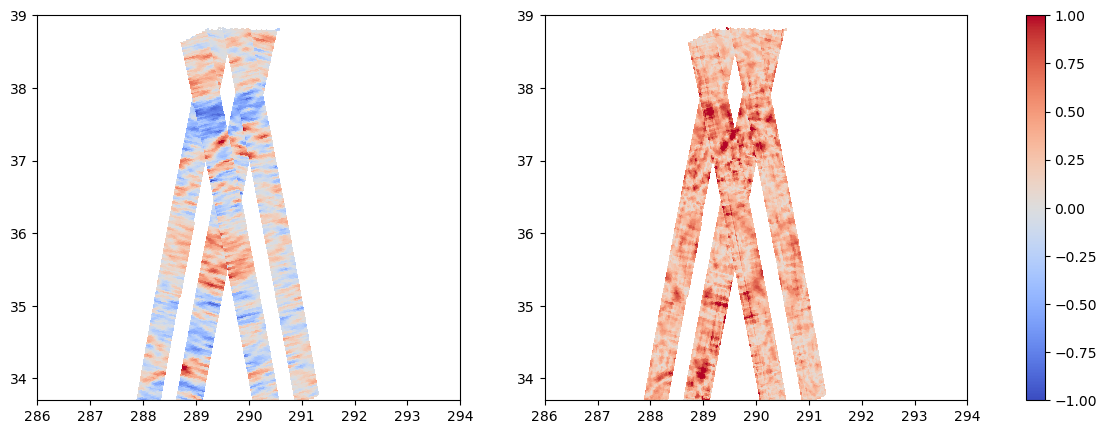

In [210]:
vel=1
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,vort,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,vort2,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('vorticity/f', rotation=270, labelpad=15)

plot = ax[1].pcolormesh(lons,lats,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,strain2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('strain/f', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39 ])
ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39 ])

<Figure size 640x480 with 0 Axes>

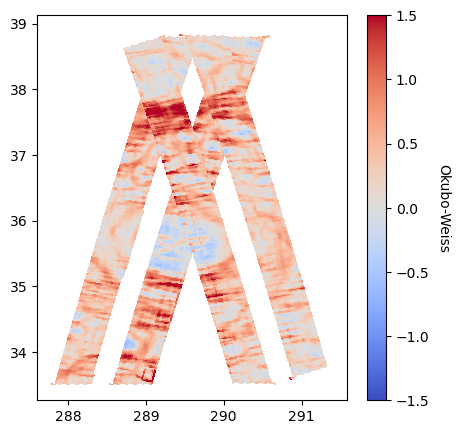

In [281]:
vel=1.5
plt.clf()

fig=plt.subplots(figsize=(5,5))


plot = plt.pcolormesh(lons,lats,strain-vort,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = plt.pcolormesh(lons2,lats2,strain2-vort2,cmap='coolwarm',vmin=-vel,vmax=vel)

cbar = plt.colorbar(plot)
cbar.set_label('Okubo-Weiss', rotation=270, labelpad=15)

In [211]:
vort_cyc,strain_cyc=compute_normalized_vorticity_strain(ds,ucyclo,vcyclo,8)
vort2_cyc,strain2_cyc=compute_normalized_vorticity_strain(ds2,ucyclo2,vcyclo2,8) 

In [214]:
pixel_num=2 #This number will change per 
vort_cyc = remove_swath_edges(vort_cyc, edge_pixels=pixel_num)
vort2_cyc = remove_swath_edges(vort2_cyc,edge_pixels=pixel_num)
strain_cyc = remove_swath_edges(strain_cyc,edge_pixels=pixel_num)
strain2_cyc = remove_swath_edges(strain2_cyc,edge_pixels=pixel_num)

In [283]:
np.shape(strain_cyc)

(318, 69)

In [284]:
ds

<xarray.Dataset> Size: 17MB
Dimensions:                                (num_lines: 318, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 176kB ...
    longitude                              (num_lines, num_pixels) float64 176kB ...
    latitude_nadir                         (num_lines) float64 3kB 33.4 ... 3...
    longitude_nadir                        (num_lines) float64 3kB 288.3 ... ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/99)
    time                                   (num_lines, num_pixels) datetime64[ns] 176kB ...
    time_tai                               (num_lines, num_pixels) datetime64[ns] 176kB ...
    ssh_karin                              (num_lines, num_pixels) float64 176kB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 176kB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 176kB ...
    ssha_karin                             (num_lines, num_pixels) float64 176kB ...
    ...                                     ...
    swh_ssb_cor_source_2                   (num_lines, num_pixels) float32 88kB ...
    wind_speed_ssb_cor_source              (num_lines, num_pixels) float32 88kB ...
    wind_speed_ssb_cor_source_2            (num_lines, num_pixels) float32 88kB ...
    volumetric_correlation                 (num_lines, num_pixels) float64 176kB ...
    volumetric_correlation_uncert          (num_lines, num_pixels) float64 176kB ...
    ssha                                   (num_lines, num_pixels) float64 176kB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2024-05-10T22:57:22Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       70.22777425719435
    ssha_variance:                                 0.1290969894990603
    references:                                    V1.2.1
    equator_longitude:                             -77.49

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

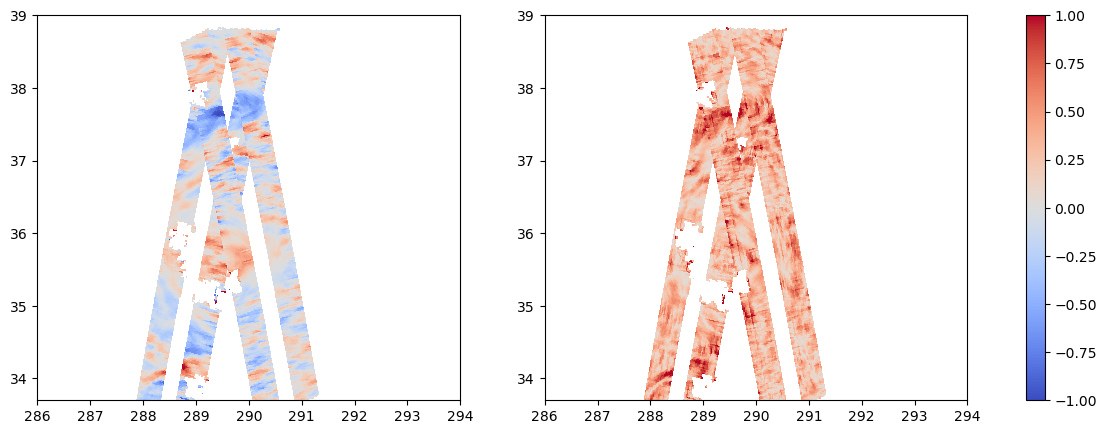

In [215]:
vel=1
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,vort_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,vort2_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('vorticity/f', rotation=270, labelpad=15)

plot = ax[1].pcolormesh(lons,lats,strain_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,strain2_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('strain/f', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39 ])

ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39 ])

In [313]:
VORT=np.append(np.squeeze(vort),np.squeeze(vort2))
STRAIN=np.append(np.squeeze(strain),np.squeeze(strain2))

GG=VORT;

STRAIN = STRAIN[~np.isnan(VORT)]
VORT = VORT[~np.isnan(VORT)]

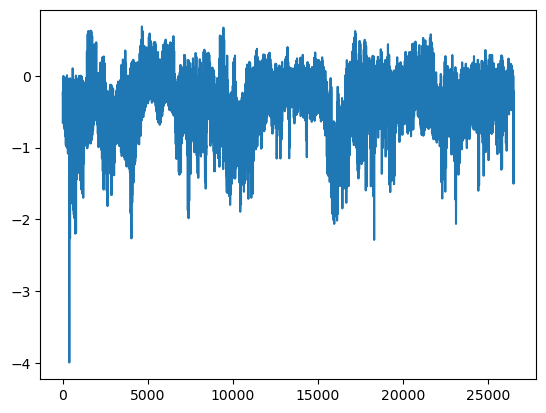

In [218]:
plt.plot(VORT-STRAIN)

In [235]:
VORT_CYC=np.append(np.squeeze(vort_cyc),np.squeeze(vort2_cyc))
STRAIN_CYC=np.append(np.squeeze(strain_cyc),np.squeeze(strain2_cyc))

STRAIN_CYC = STRAIN_CYC[~np.isnan(VORT_CYC)]
VORT_CYC = VORT_CYC[~np.isnan(VORT_CYC)]

VORT_CYC = VORT_CYC[~np.isnan(STRAIN_CYC)]
STRAIN_CYC = STRAIN_CYC[~np.isnan(STRAIN_CYC)]

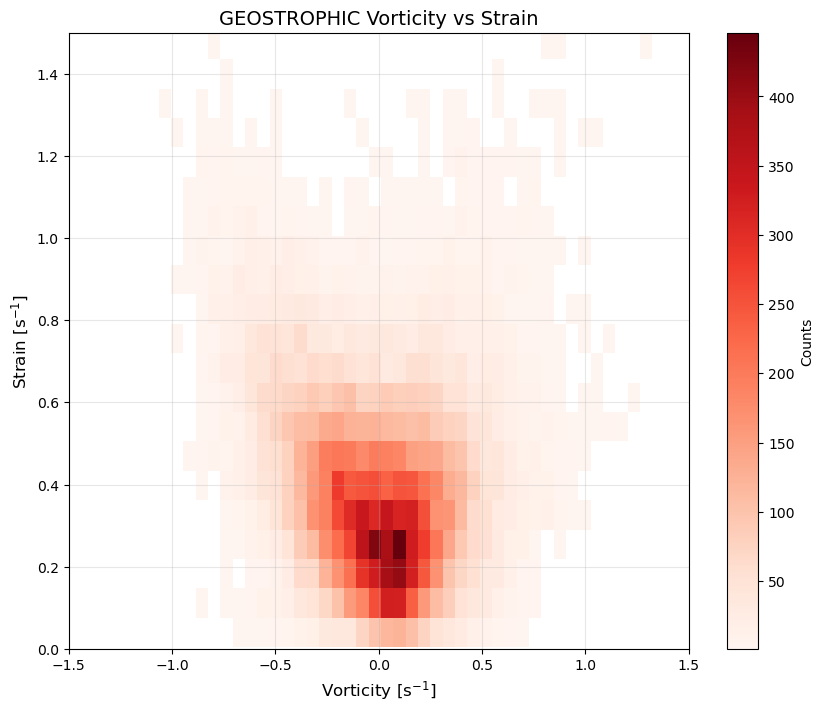

In [257]:
# Set default parameters if not provided
default_kwargs = {
    'bins': (50,50),
    'cmap': 'Reds',
    'density': False
}

# Update defaults with user-provided kwargs
plot_kwargs = default_kwargs.copy()
plot_kwargs.update(default_kwargs)

# Create the 2D histogram
plt.figure(figsize=(10, 8))
h = plt.hist2d(VORT,STRAIN, **plot_kwargs,cmin=0.1)
plt.ylim(0,1.5)
plt.xlim(-1.5,1.5)

# Add colorbar
cbar = plt.colorbar(h[3], label='Counts')

# Add labels and title
plt.xlabel('Vorticity [s$^{-1}$]', fontsize=12)
plt.ylabel('Strain [s$^{-1}$]', fontsize=12)
plt.title('GEOSTROPHIC Vorticity vs Strain', fontsize=14)

# Add grid for better readability
plt.grid(True, alpha=0.3)

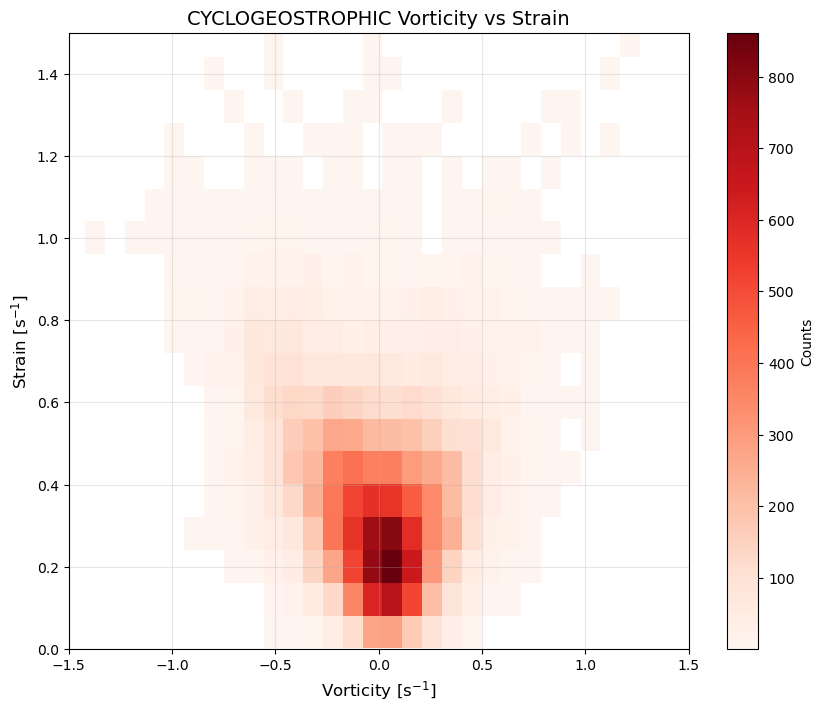

In [258]:
# Set default parameters if not provided
default_kwargs = {
    'bins': (50,50),
    'cmap': 'Reds',
    'density': False
}

# Update defaults with user-provided kwargs
plot_kwargs = default_kwargs.copy()
plot_kwargs.update(default_kwargs)

# Create the 2D histogram
plt.figure(figsize=(10, 8))
h = plt.hist2d(VORT_CYC,STRAIN_CYC, **plot_kwargs,cmin=0.1)
plt.ylim(0,1.5)
plt.xlim(-1.5,1.5)

# Add colorbar
cbar = plt.colorbar(h[3], label='Counts')

# Add labels and title
plt.xlabel('Vorticity [s$^{-1}$]', fontsize=12)
plt.ylabel('Strain [s$^{-1}$]', fontsize=12)
plt.title('CYCLOGEOSTROPHIC Vorticity vs Strain', fontsize=14)

# Add grid for better readability
plt.grid(True, alpha=0.3)

In [300]:
moana_ds = xr.open_dataset('data/moana/moana_Edward_05082024.nc') # should rename this with file extention .ncs
mlon = moana_ds.variables['longitude'] + 360
mlat = moana_ds.variables['latitude'] 
pro = moana_ds.variables['prococcus_moana']
pico = moana_ds.variables['picoeuk_moana'] 
syn = moana_ds.variables['syncoccus_moana'] 
chl= moana_ds.variables['chlor_a'] 
poc= moana_ds.variables['poc'] 

In [301]:
# Let's interpolate MOANA onto SWOT Level-2 grids for each swot dataset
# This will take a long time!
pro1 = griddata((mlon.values.ravel(),mlat.values.ravel()), pro.values.ravel(), (ds.longitude.values, ds.latitude.values), method='linear')
pro2 = griddata((mlon.values.ravel(),mlat.values.ravel()), pro.values.ravel(), (ds2.longitude.values, ds2.latitude.values), method='linear')

In [302]:
pico1 = griddata((mlon.values.ravel(),mlat.values.ravel()), pico.values.ravel(), (ds.longitude.values, ds.latitude.values), method='linear')
pico2 = griddata((mlon.values.ravel(),mlat.values.ravel()), pico.values.ravel(), (ds2.longitude.values, ds2.latitude.values), method='linear')

In [303]:
syn1 = griddata((mlon.values.ravel(),mlat.values.ravel()), syn.values.ravel(), (ds.longitude.values, ds.latitude.values), method='linear')
syn2 = griddata((mlon.values.ravel(),mlat.values.ravel()), syn.values.ravel(), (ds2.longitude.values, ds2.latitude.values), method='linear')

In [304]:
chl1 = griddata((mlon.values.ravel(),mlat.values.ravel()), chl.values.ravel(), (ds.longitude.values, ds.latitude.values), method='linear')
chl2 = griddata((mlon.values.ravel(),mlat.values.ravel()), chl.values.ravel(), (ds2.longitude.values, ds2.latitude.values), method='linear')

In [459]:
PRO=np.append(np.squeeze(pro1),np.squeeze(pro2))
PICO=np.append(np.squeeze(pico1),np.squeeze(pico2))
SYN=np.append(np.squeeze(syn1),np.squeeze(syn2))
CHL=np.append(np.squeeze(chl1),np.squeeze(chl2))
LAT=np.append(np.squeeze(ds.latitude.values),np.squeeze(ds2.latitude.values))
LON=np.append(np.squeeze(ds.longitude.values),np.squeeze(ds2.longitude.values))

In [460]:
CHL_NONAN = CHL[~np.isnan(GG)] #GG is the original VORT array without NaNing... sorry for the bad variable naming
PICO_NONAN = PICO[~np.isnan(GG)]
PRO_NONAN = PRO[~np.isnan(GG)]
SYN_NONAN = SYN[~np.isnan(GG)]
LAT_NONAN=LAT[~np.isnan(GG)]
LON_NONAN=LON[~np.isnan(GG)]

# plt.scatter(STRAIN-VORT,SYN_NONAN)

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

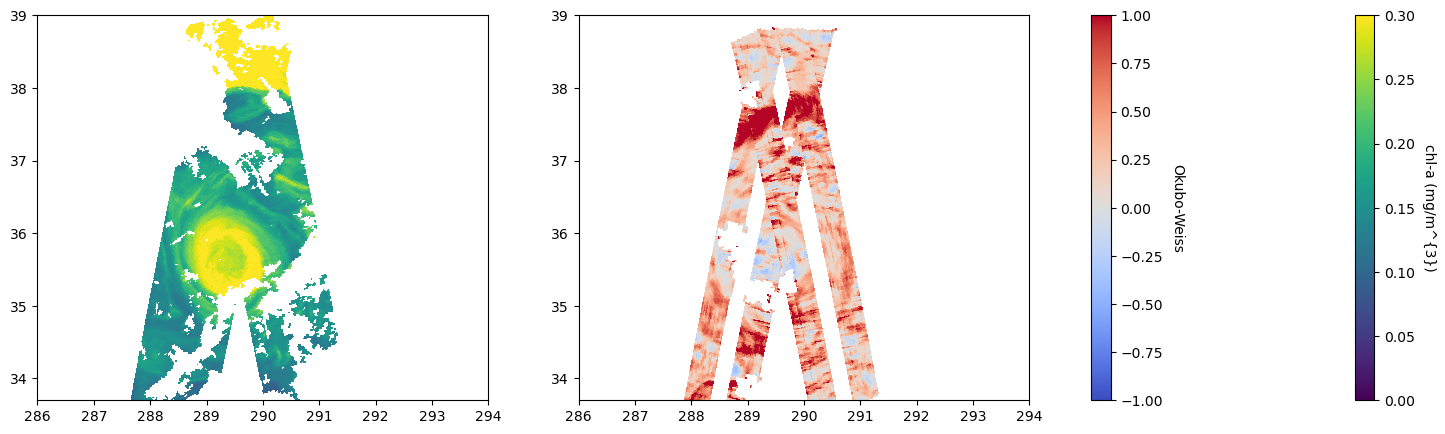

In [359]:
vel=1
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(20,5))

plot = ax[0].pcolormesh(lons,lats,chl1,cmap='viridis',vmin=-0,vmax=0.3)
plot = ax[0].pcolormesh(lons2,lats2,chl2,cmap='viridis',vmin=-0,vmax=0.3)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('chl-a (mg/m^{3})', rotation=270, labelpad=15)

plot = ax[1].pcolormesh(lons,lats,strain_cyc-vort_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,strain2_cyc-vort2_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('Okubo-Weiss', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39 ])

ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39])

In [467]:
max_lat=37 #cut off gulf stream
# mask = (lons >= min_lon) & (lons <= max_lon) & (lats >= min_lat) & (lats <= max_lat)
mask = (LAT_NONAN <= max_lat)
CHL_CROP=CHL_NONAN[mask]
VORT_CROP=VORT[mask]
STRAIN_CROP=STRAIN[mask]
PICO_CROP=PICO_NONAN[mask]
PRO_CROP=PRO_NONAN[mask]
SYN_CROP=SYN_NONAN[mask]

In [ ]:
PACE_NAN_IDX=CHL_CROP

In [ ]:
CHL_CROP=CHL_CROP[~np.isnan(PACE_NAN_IDX)]
VORT_CROP=VORT_CROP[~np.isnan(PACE_NAN_IDX)]
STRAIN_CROP=STRAIN_CROP[~np.isnan(PACE_NAN_IDX)]
PICO_CROP=PICO_CROP[~np.isnan(PACE_NAN_IDX)]
PRO_CROP=PRO_CROP[~np.isnan(PACE_NAN_IDX)]
SYN_CROP=SYN_CROP[~np.isnan(PACE_NAN_IDX)]

In [ ]:
resolution=0.1

In [385]:
vort_reg = np.arange(-2.1, 2, 0.05)
strain_reg = np.arange(0, 2, 0.05)

In [386]:
vort_reg

array([-2.10000000e+00, -2.00000000e+00, -1.90000000e+00, -1.80000000e+00,
       -1.70000000e+00, -1.60000000e+00, -1.50000000e+00, -1.40000000e+00,
       -1.30000000e+00, -1.20000000e+00, -1.10000000e+00, -1.00000000e+00,
       -9.00000000e-01, -8.00000000e-01, -7.00000000e-01, -6.00000000e-01,
       -5.00000000e-01, -4.00000000e-01, -3.00000000e-01, -2.00000000e-01,
       -1.00000000e-01,  1.77635684e-15,  1.00000000e-01,  2.00000000e-01,
        3.00000000e-01,  4.00000000e-01,  5.00000000e-01,  6.00000000e-01,
        7.00000000e-01,  8.00000000e-01,  9.00000000e-01,  1.00000000e+00,
        1.10000000e+00,  1.20000000e+00,  1.30000000e+00,  1.40000000e+00,
        1.50000000e+00,  1.60000000e+00,  1.70000000e+00,  1.80000000e+00,
        1.90000000e+00])

In [420]:
vort_reg_mesh, strain_reg_mesh = np.meshgrid(vort_reg, strain_reg)

In [469]:
chl_vs_space = griddata((VORT_CROP,STRAIN_CROP), CHL_CROP, (vort_reg_mesh,strain_reg_mesh), method='linear')
pico_vs_space = griddata((VORT_CROP,STRAIN_CROP), PICO_CROP, (vort_reg_mesh,strain_reg_mesh), method='linear')
pro_vs_space = griddata((VORT_CROP,STRAIN_CROP), PRO_CROP, (vort_reg_mesh,strain_reg_mesh), method='linear')
syn_vs_space = griddata((VORT_CROP,STRAIN_CROP), SYN_CROP, (vort_reg_mesh,strain_reg_mesh), method='linear')

/tmp/ipykernel_144/2228715960.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(plot)


Text(0, 0.5, '$\\sigma$/f')

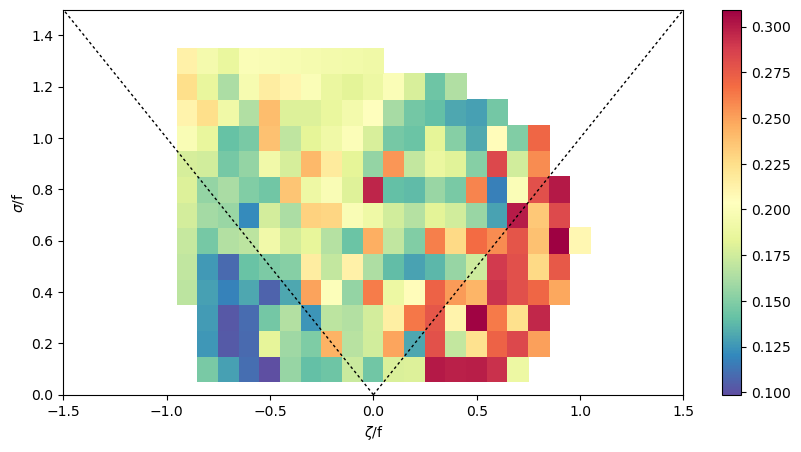

In [491]:
fig=plt.subplots(figsize=(10,5))
plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,chl_vs_space,cmap='Spectral_r')
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
plt.ylim(0,1.5)
plt.xlim(-1.5,1.5)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')

/tmp/ipykernel_144/1948077508.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(plot)


Text(0, 0.5, '$\\sigma$/f')

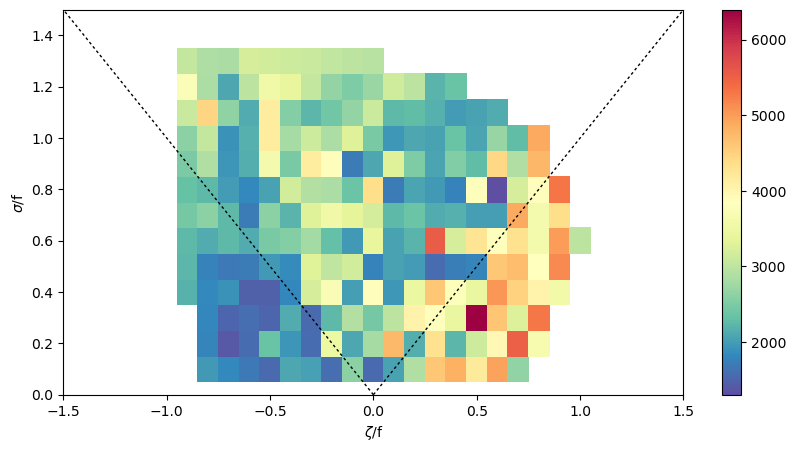

In [492]:
fig=plt.subplots(figsize=(10,5))
plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,pico_vs_space,cmap='Spectral_r')
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
plt.ylim(0,1.5)
plt.xlim(-1.5,1.5)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')

/tmp/ipykernel_144/1841464600.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(plot)


Text(0, 0.5, '$\\sigma$/f')

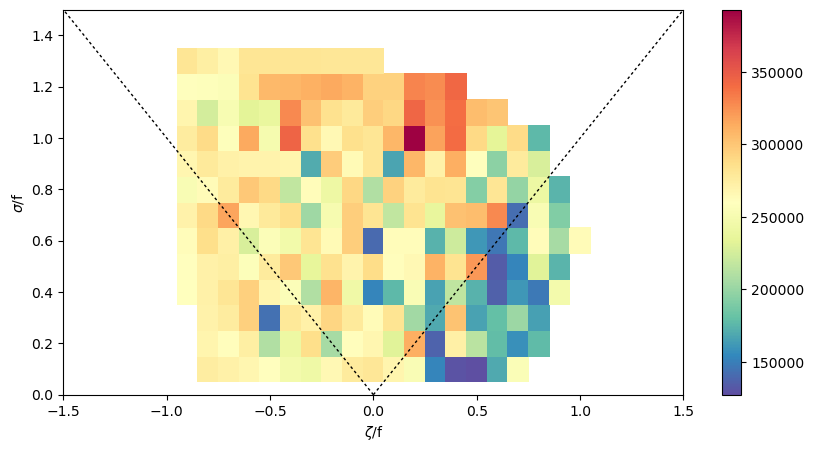

In [493]:
fig=plt.subplots(figsize=(10,5))
plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,pro_vs_space,cmap='Spectral_r')
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
plt.ylim(0,1.5)
plt.xlim(-1.5,1.5)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')

/tmp/ipykernel_144/131228536.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(plot)


Text(0, 0.5, '$\\sigma$/f')

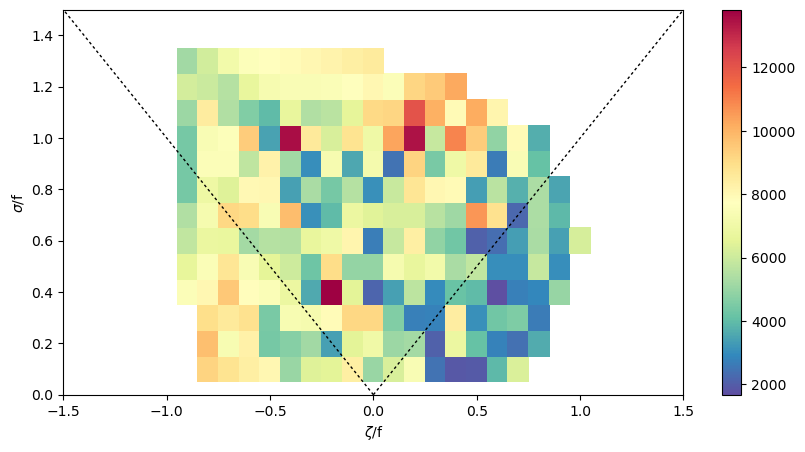

In [494]:
fig=plt.subplots(figsize=(10,5))
plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,syn_vs_space,cmap='Spectral_r')
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
plt.ylim(0,1.5)
plt.xlim(-1.5,1.5)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')

/tmp/ipykernel_144/1743561759.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(plot)


Text(0, 0.5, '$\\sigma$/f')

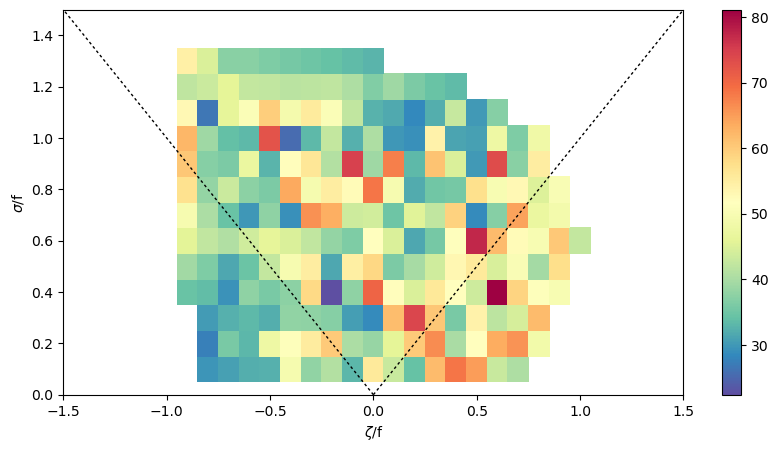

In [495]:
fig=plt.subplots(figsize=(10,5))
plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,pro_vs_space/syn_vs_space,cmap='Spectral_r')
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
plt.ylim(0,1.5)
plt.xlim(-1.5,1.5)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')

/tmp/ipykernel_144/3166047949.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(plot)


Text(0, 0.5, '$\\sigma$/f')

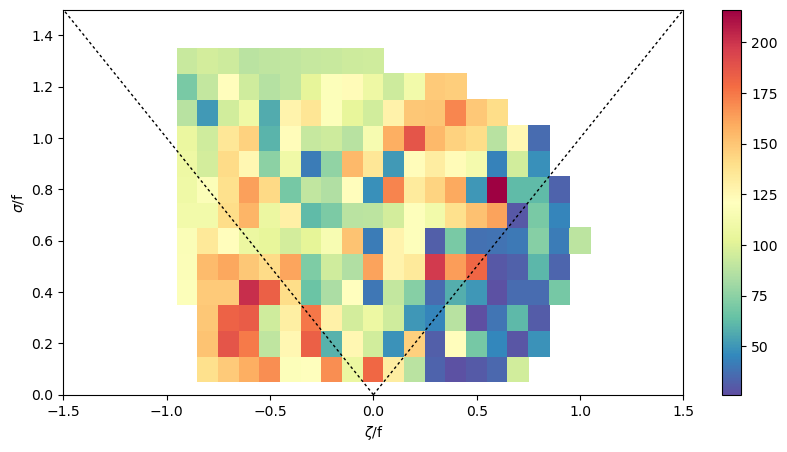

In [496]:
fig=plt.subplots(figsize=(10,5))
plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,pro_vs_space/pico_vs_space,cmap='Spectral_r')
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
plt.ylim(0,1.5)
plt.xlim(-1.5,1.5)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')